In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [2]:
df.shape

(45000, 15)

In [3]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

In [5]:
df.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [6]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [7]:
df["Placement_Status"].value_counts()

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64

In [8]:
df.dtypes

Student_ID                int64
Age                       int64
Gender                   object
Degree                   object
Branch                   object
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
Placement_Status         object
dtype: object

In [9]:
df = df.drop("Student_ID", axis=1)

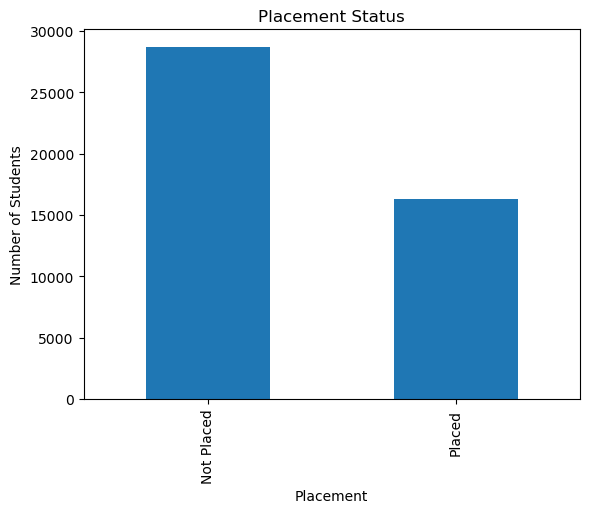

In [10]:
import matplotlib.pyplot as plt

df["Placement_Status"].value_counts().plot(kind="bar")
plt.title("Placement Status")
plt.xlabel("Placement")
plt.ylabel("Number of Students")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Placement_Status"] = le.fit_transform(df["Placement_Status"])

In [14]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Degree', 'Branch'], dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["Gender", "Degree", "Branch"]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [16]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,0,1,2,6.29,0,3,4,6,51,5,1,3,0
1,20,0,2,2,6.05,1,4,6,8,59,8,2,1,0
2,22,1,3,4,7.22,1,4,6,6,58,6,2,2,0
3,22,1,3,4,7.78,2,4,6,6,90,4,2,0,1
4,20,0,1,4,7.63,1,4,6,5,79,6,2,0,1


In [17]:
X = df.drop("Placement_Status", axis=1)

y = df["Placement_Status"]

In [18]:
print(X.shape)
print(y.shape)

(45000, 13)
(45000,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)

(36000, 13)
(9000, 13)


In [21]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,0,1,2,6.29,0,3,4,6,51,5,1,3,0
1,20,0,2,2,6.05,1,4,6,8,59,8,2,1,0
2,22,1,3,4,7.22,1,4,6,6,58,6,2,2,0
3,22,1,3,4,7.78,2,4,6,6,90,4,2,0,1
4,20,0,1,4,7.63,1,4,6,5,79,6,2,0,1


In [22]:
print(X_train.shape)

(36000, 13)


In [23]:
print(X_test.shape)

(9000, 13)


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression(max_iter=1000)

In [26]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.864


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[5133  576]
 [ 648 2643]]


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5709
           1       0.82      0.80      0.81      3291

    accuracy                           0.86      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.86      0.86      0.86      9000



In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9263333333333333


In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.864000
1        Decision Tree  1.000000
2        Random Forest  1.000000
3                  KNN  0.926333


In [35]:
print("Training Accuracy:", rf.score(X_train, y_train))
print("Testing Accuracy:", rf.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [36]:
import joblib

joblib.dump(rf, "placement_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [37]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']